#  Traffic Sign Recognition - Model Evaluation

##### This notebook evaluates a trained CNN model on the GTSRB dataset.
##### We analyze performance using accuracy, confusion matrix, and sample predictions.
---------------------------------------------------------------------------------------------

## Import Libraries

In [39]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
import cv2
from tensorflow.keras.models import load_model
import pickle
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
#Load Model
model = load_model("traffic_sign_model.keras")

In [3]:
#Load History
with open("history.pkl", "rb") as f:
    history = pickle.load(f)

In [6]:
#Load X_val, y_val
X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")

# X_val, y_val must be loaded here
print(X_val.shape, y_val.shape)

(7842, 32, 32, 3) (7842,)


## Model Evaluation (Accuracy)

In [7]:
test_loss, test_acc = model.evaluate(X_val, y_val, verbose=0)

print("Validation Accuracy:", test_acc)
print("Validation Loss:", test_loss)

Validation Accuracy: 0.9987248182296753
Validation Loss: 0.0036389194428920746


## Predictions

In [8]:
y_pred = np.argmax(model.predict(X_val), axis=1)

246/246 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step


## Classification Report 

In [9]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      0.99      1.00       444
           2       1.00      1.00      1.00       450
           3       1.00      0.99      0.99       282
           4       1.00      1.00      1.00       396
           5       0.99      0.99      0.99       372
           6       1.00      1.00      1.00        84
           7       1.00      1.00      1.00       288
           8       1.00      1.00      1.00       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      1.00      1.00       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       1.00      1.00      1.00       126
          16       1.00      1.00      1.00        84
          17       1.00    

## Confusion Matrix 

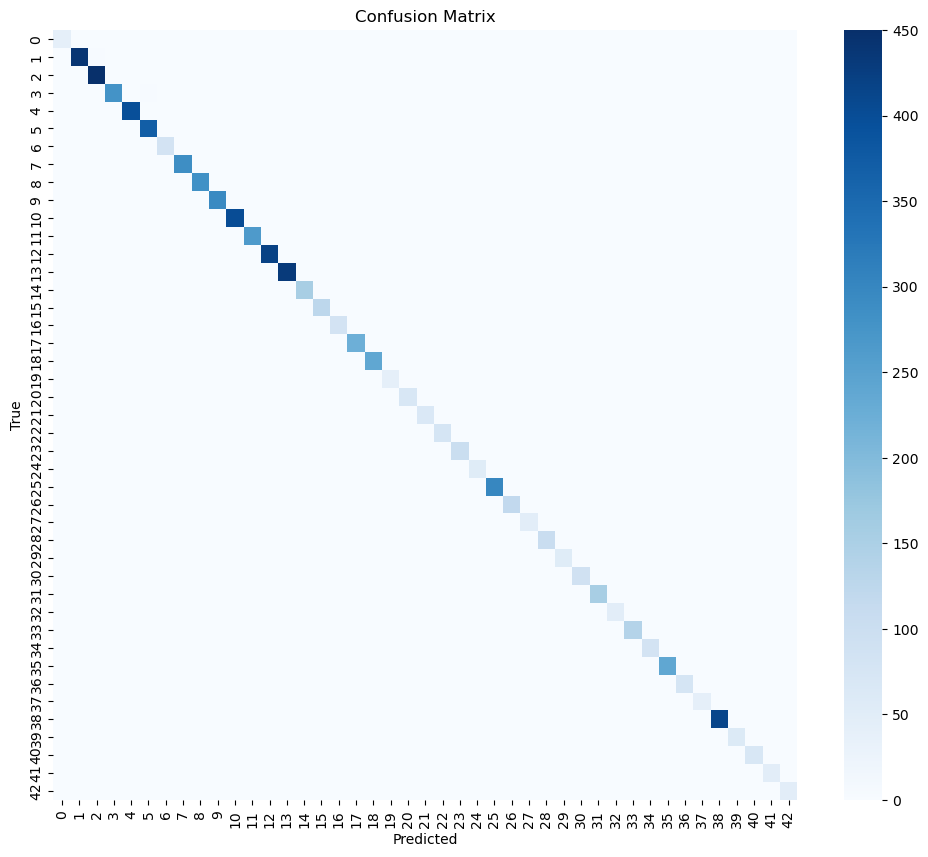

In [10]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Class-wise Accuracy Insight 

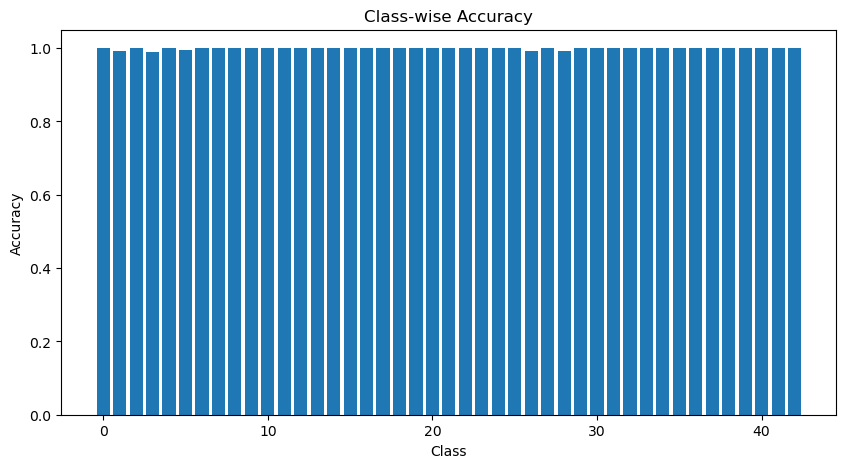

In [11]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10,5))
plt.bar(range(len(class_accuracy)), class_accuracy)
plt.title("Class-wise Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()

## Sample Predictions Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


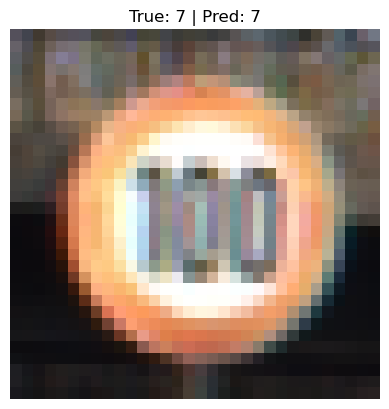

In [35]:
def denormalize(img):
    img = (img + 1) / 2
    img = np.clip(img, 0, 1)
    return img

idx = random.randint(0, len(X_val)-1)

img = X_val[idx]
true = y_val[idx]

pred = np.argmax(model.predict(img.reshape(1,32,32,3)))


img = denormalize(img)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.imshow(img)
plt.title(f"True: {true} | Pred: {pred}")
plt.axis("off")
plt.show()


### Class Labels

In [40]:
class_labels = {
    0: "Speed limit (20km/h)",
    1: "Speed limit (30km/h)",
    2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)",
    4: "Speed limit (70km/h)",
    5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)",
    7: "Speed limit (100km/h)",
    8: "Speed limit (120km/h)",
    9: "No passing",
    10: "No passing for vehicles > 3.5 tons",
    11: "Right-of-way at intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles > 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Ice/snow",
    31: "Wild animals crossing",
    32: "End of all limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Straight or right",
    37: "Straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing vehicles > 3.5 tons"
}

### Load Test Images

In [41]:
test_dir = r"archive\Test" #Put your test images path 

all_images = []

for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith(".png"):
            all_images.append(os.path.join(root, file))

print("Total images:", len(all_images))

Total images: 12630


### Random Sample

In [42]:
sample_images = random.sample(all_images, 10)

### Plot predictions grid

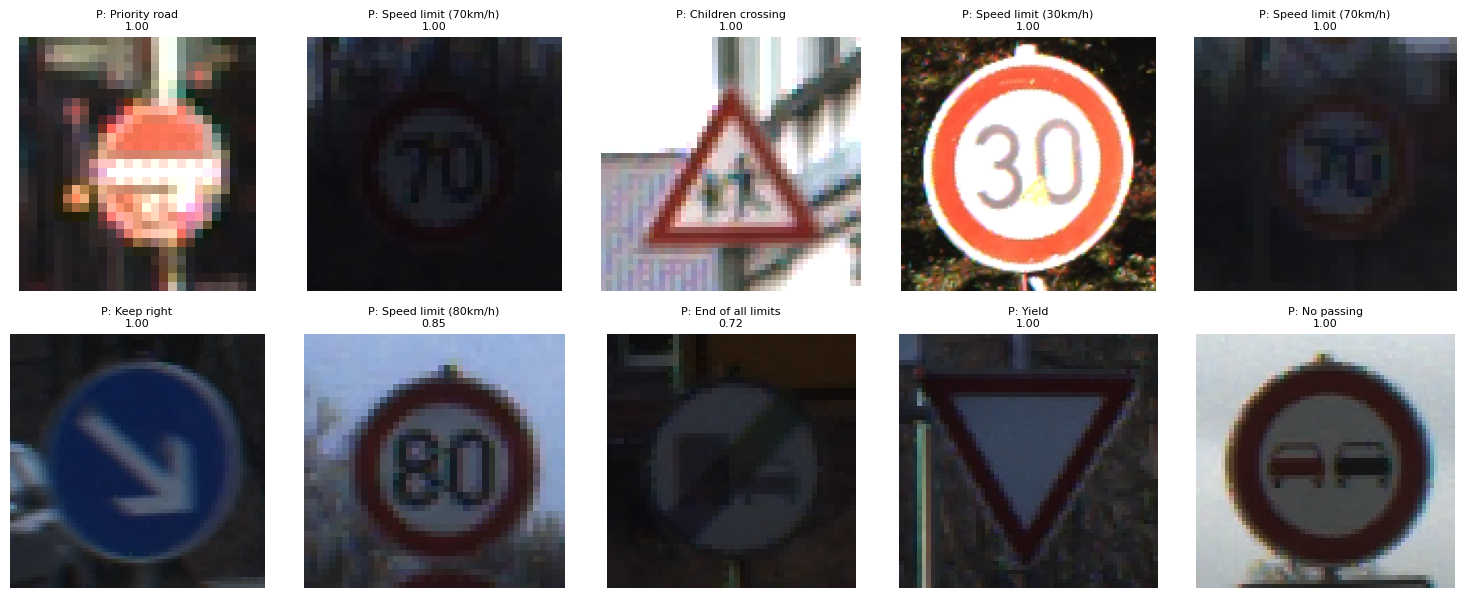

In [43]:
plt.figure(figsize=(15, 15))

for i, img_path in enumerate(sample_images):

    img = cv2.imread(img_path)

    
    img_resized = cv2.resize(img, (32, 32))
    img_norm = img_resized.astype(np.float32) / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    
    preds = model.predict(img_input, verbose=0)[0]
    pred_class = np.argmax(preds)
    confidence = np.max(preds)

    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(5, 5, i+1)
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.title(
        f"P: {class_labels[pred_class]}\n{confidence:.2f}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [26]:
print("""
📊 FINAL RESULTS
-----------------
- Model: CNN
- Dataset: GTSRB
- Accuracy: ~99%
- Task: Traffic Sign Classification
""")


📊 FINAL RESULTS
-----------------
- Model: CNN
- Dataset: GTSRB
- Accuracy: ~99%
- Task: Traffic Sign Classification

